In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d


from scipy import stats
import statsmodels.formula.api as smf


# For TF analysis
import scipy.fftpack
from scipy.fftpack import fft, ifft
from scipy import signal

# For CSD analysis
import Python3_icsd as icsd 
import scipy.signal as sg
import quantities as pq

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

import matplotlib.animation as ani #this was a good idea that I didn't want to spend time on right now

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

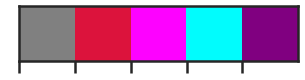

In [3]:
pal=sns.blend_palette(['gray','crimson','magenta','cyan','purple'],5)
sns.palplot(pal)
sns.set_palette(pal)

# Load some necessary variables

In [4]:
def round_up(value):
    rou = int(np.ceil(value/100))*100
    return rou

def round_down(value):
    rou = int(np.floor(value/100))*100
    return rou

In [5]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


---

---

---

# For multiple mice

In [6]:
start_path_ls=glob.glob(r"D:/mz_Data/RECORDING_DATA/operant/raw_data/"+'novel*')
end_path = r"\continuous\Neuropix-PXI-100.1\continuous.dat"

samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

alldatals=[]
CC_ls = []
et_ls = []
for start_path in start_path_ls:
    ls = []
    CC_num = start_path.split('\\')[-1].split('_')[1]
    et = start_path.split('\\')[-1].split('_')[1] + "_" + start_path.split('\\')[-1].split('_')[2]
    
    for i in range(6, 55): # remember, you have to exclude the first short TTL signal trials
        exp_rec_path = rf"\experiment1\recording{i}"
        fileName = start_path + exp_rec_path + end_path
        data = np.memmap(fileName, dtype='int16', mode='c')
        data2 = data.reshape(-1, n_chan)
        ls.append(data2[:samples_tr, 0:384])
        
    alldatals.append(ls)
    CC_ls.append(CC_num)
    et_ls.append(et)

# alldatals # 16 x 49 x 7350 x 384
et_ls


['CC067431_HP2',
 'CC067432_HP4',
 'CC067489_HP2',
 'CC067489_HP3',
 'CC082255_HP3',
 'CC082257_HP1',
 'CC082257_HP2',
 'CC082257_HP3',
 'CC082260_HP2',
 'CC082260_HP3',
 'CC082260_HP4',
 'CC082263_HP1',
 'CC082263_HP2',
 'CC082263_HP3',
 'CC084621_HP1',
 'CC084621_HP2']

---

---

---

# Keep working from here

In [7]:
times = np.linspace(0, samples_tr/sr, samples_tr)
scale_factor = 0.195
time_arr = [0,0.5,1,1.5,2,2.5]
time_plot = [i*sr for i in time_arr]

allrecsls=[]
for i in range(len(alldatals)):
    tmp2 = np.mean(alldatals[i], axis = 0)           # getting the mean traces over all trials
    tmp2 = tmp2.T

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    filt_tmp2 = []
    for ch in range(tmp2.shape[0]):
        ch_data = tmp2[ch,:]
        ch_notc_data = mz_LFP.notch_filt(ch_data)
        filt_tmp2.append(ch_notc_data)
    filt_tmp2 = np.array(filt_tmp2)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    CARfilt_tmp2 = mz_LFP.applyCAR(filt_tmp2, pr=0)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    scaled_CARfilt_tmp2 = CARfilt_tmp2*scale_factor
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    allrecsls.append(scaled_CARfilt_tmp2)
    print('Loaded {0}'.format(i))
    
allrecs_arr = np.array(allrecsls)


Loaded 0
Loaded 1
Loaded 2
Loaded 3
Loaded 4
Loaded 5
Loaded 6
Loaded 7
Loaded 8
Loaded 9
Loaded 10
Loaded 11
Loaded 12
Loaded 13
Loaded 14
Loaded 15


In [8]:
allrecs_arr.shape

(16, 384, 7350)

---

In [9]:
CC_ls

['CC067431',
 'CC067432',
 'CC067489',
 'CC067489',
 'CC082255',
 'CC082257',
 'CC082257',
 'CC082257',
 'CC082260',
 'CC082260',
 'CC082260',
 'CC082263',
 'CC082263',
 'CC082263',
 'CC084621',
 'CC084621']

In [18]:
wt_novel = []
fx_novel = []

for idx, cc in enumerate(CC_ls):
    if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"): #wt
        wt_novel.append(allrecs_arr[idx])
    elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"): #fx
        fx_novel.append(allrecs_arr[idx])

wt_novel = np.array(wt_novel)
fx_novel = np.array(fx_novel)

In [28]:
strain = input('What type of mouse ("wt", "fx"): ')

if strain == 'wt':
    working_data = wt_novel
    data_id = 'WT'
elif strain == 'fx':
    working_data = fx_novel
    data_id = 'FX'
else:
    raise Exception('Input is not one of the options')

What type of mouse ("wt", "fx"): fx


discrete filter coefficients: 
b = [ 0.375 0.487 0.607 0.726 0.835 0.923 0.980 1.000 0.980 0.923 0.835 0.726 0.607 0.487 0.375 ], 
a = [ 10.867 ]


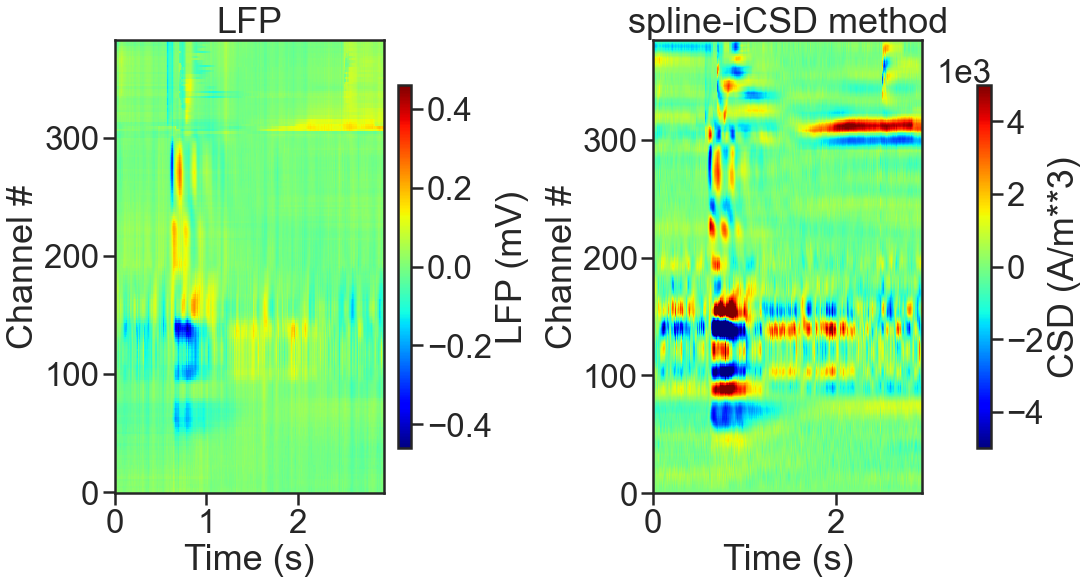

discrete filter coefficients: 
b = [ 0.375 0.487 0.607 0.726 0.835 0.923 0.980 1.000 0.980 0.923 0.835 0.726 0.607 0.487 0.375 ], 
a = [ 10.867 ]


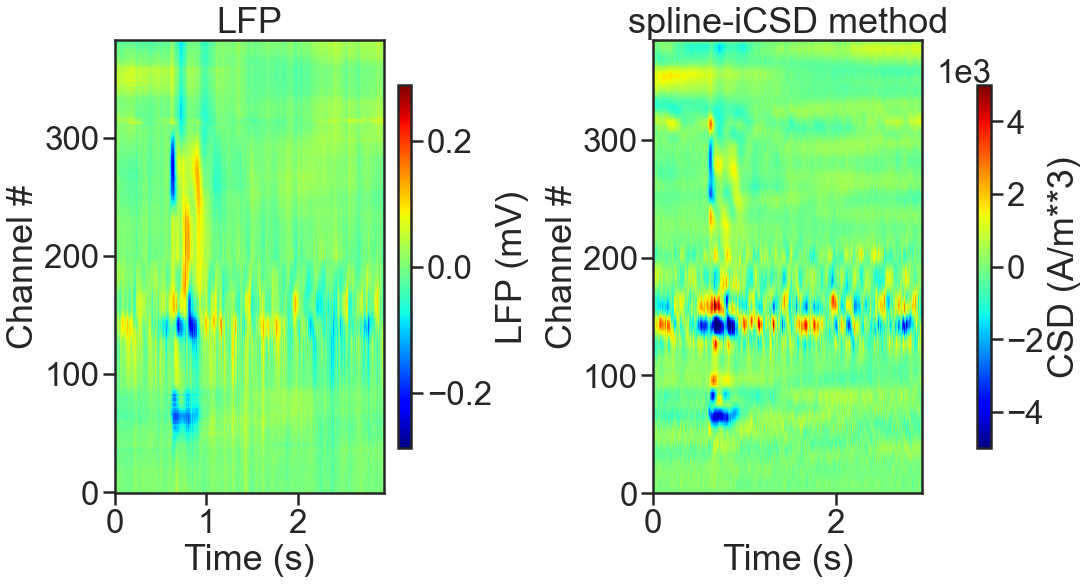

discrete filter coefficients: 
b = [ 0.375 0.487 0.607 0.726 0.835 0.923 0.980 1.000 0.980 0.923 0.835 0.726 0.607 0.487 0.375 ], 
a = [ 10.867 ]


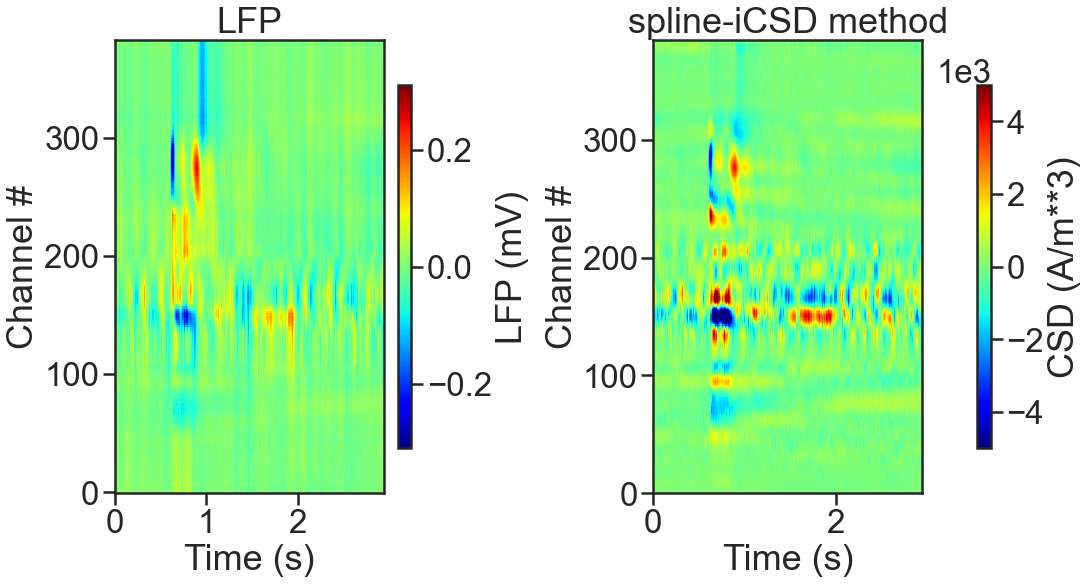

discrete filter coefficients: 
b = [ 0.375 0.487 0.607 0.726 0.835 0.923 0.980 1.000 0.980 0.923 0.835 0.726 0.607 0.487 0.375 ], 
a = [ 10.867 ]


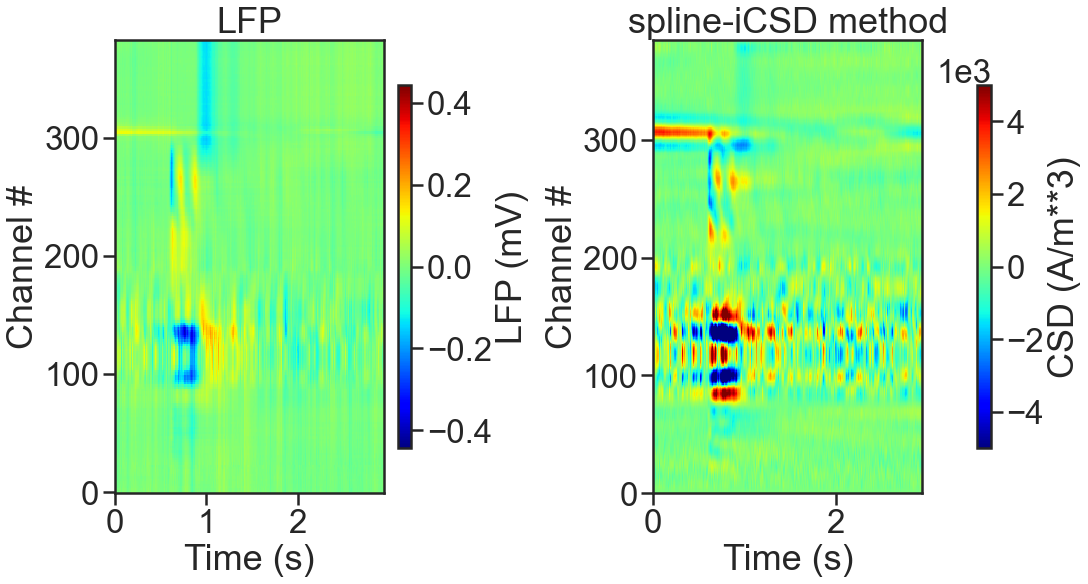

discrete filter coefficients: 
b = [ 0.375 0.487 0.607 0.726 0.835 0.923 0.980 1.000 0.980 0.923 0.835 0.726 0.607 0.487 0.375 ], 
a = [ 10.867 ]


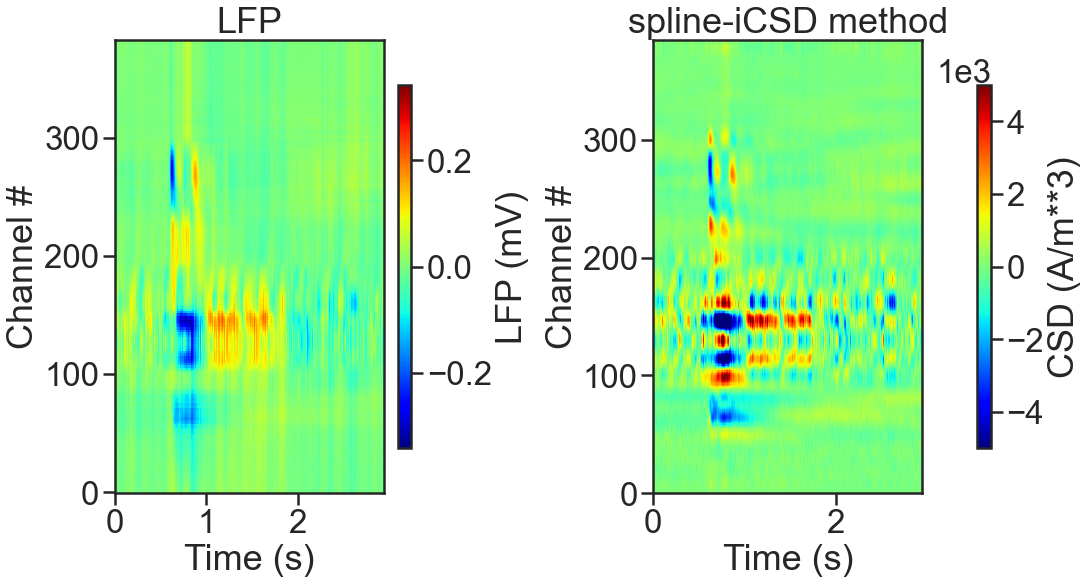

discrete filter coefficients: 
b = [ 0.375 0.487 0.607 0.726 0.835 0.923 0.980 1.000 0.980 0.923 0.835 0.726 0.607 0.487 0.375 ], 
a = [ 10.867 ]


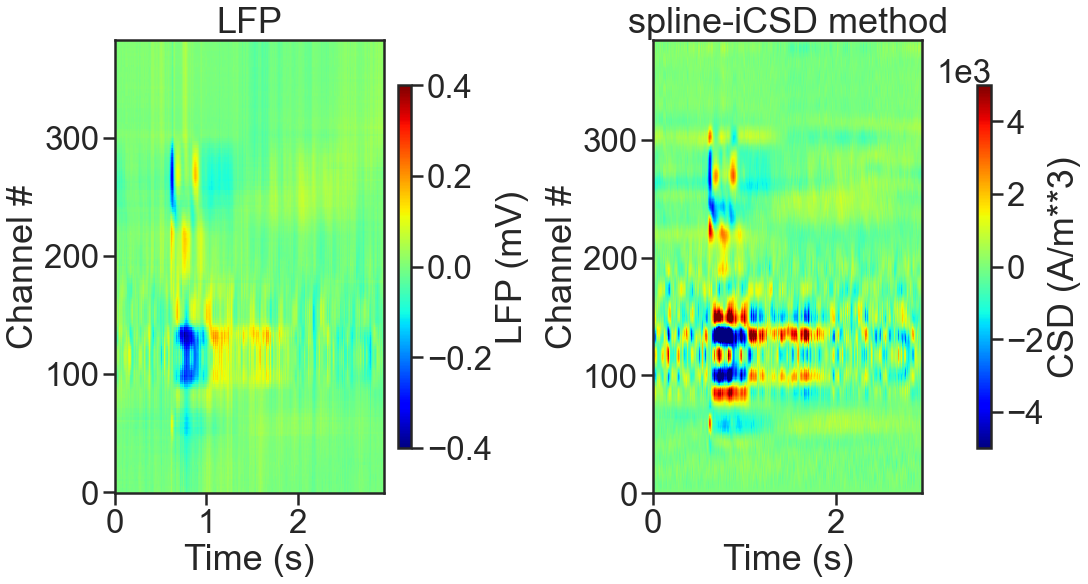

In [29]:
# this is a list of the channel x-position along the probe: ch0 at the tip, ch384 at the base
ch_y_pos_ls = [43,11,59,27]
ch_y_pos = np.array(ch_y_pos_ls*int(384/4)) #this repeats the above ls 384/4 times

all_mice_csd = []
for mouse in range(len(working_data)):
    
    single_mouse_lfp = working_data[mouse]
    
    col_ls = []
    for idx, val in enumerate(ch_y_pos):
        if (val == 43) | (val == 59): # all x-values are (43, 11, 59, 27), max and min y-values are (20, 3840)
            col_ls.append(single_mouse_lfp[idx])
    col_arr = np.array(col_ls)
    
    f,ax=plt.subplots(1,2,figsize=(15,8), constrained_layout=True)
    ch_num = col_arr.shape[0]
    csd = mz_LFP.df_CSD_analysis(data=col_arr, axes=ax, Channel_Number=ch_num, up_samp=2)
    plt.show()
    
    foo_csd = np.array(csd)
    all_mice_csd.append(foo_csd)

In [30]:
all_mice_csd = np.array(all_mice_csd)
all_mice_mean = np.mean(all_mice_csd, axis=0)

up_samp = 2
title_str = 'All {0} - '.format(strain) + 'Novel'

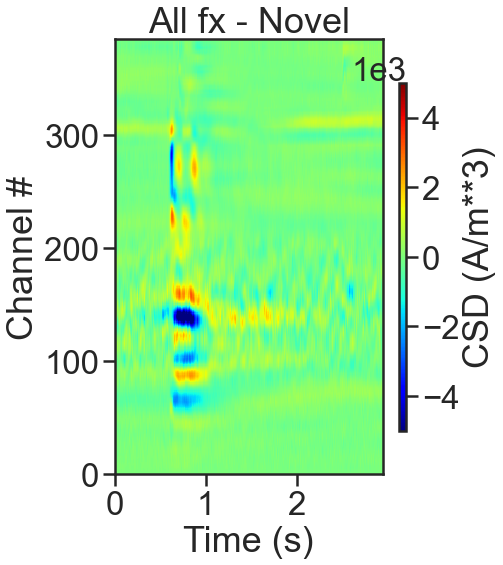

In [31]:
plt.figure(figsize=(6,8))

im = plt.imshow(all_mice_mean, origin='lower', 
                vmin=-5000, vmax=5000,
                cmap='jet', interpolation='nearest',aspect='auto')


plt.title(title_str)
plt.ylabel('Channel #')
plt.xlabel('Time (s)')
plt.xticks([0, 1*2500, 2*2500], labels=[0,1,2])

cb = plt.colorbar(im, aspect=50, shrink=0.8)
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.set_label('CSD (%s)' % csd.dimensionality.string)

# Change the end of this next line with a new file name!!
plt.savefig(r"U:\Data\zimmer94\Operant_Reward\lfp\CSD\1sec\averages\fx_avg_novel.pdf", transparent=True)

plt.show()

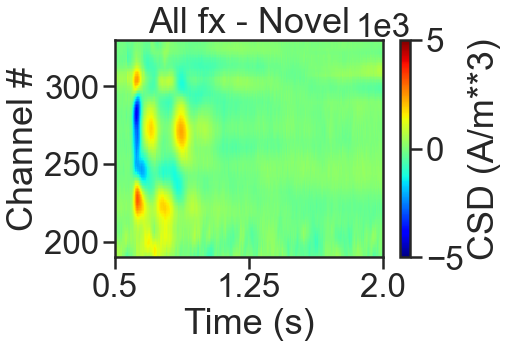

In [32]:
plt.figure(figsize=(6,4))

im = plt.imshow(all_mice_mean, origin='lower', 
                vmin=-5000, vmax=5000,
                cmap='jet', interpolation='nearest',aspect='auto')


plt.title(title_str)
plt.ylabel('Channel #')
plt.xlabel('Time (s)')
plt.ylim([190,330])
plt.xlim([0.5*2500, 2.0*2500])
plt.xticks([0.5*2500, 1.25*2500, 2.0*2500], labels=[0.5,1.25,2.0])

cb = plt.colorbar(im, aspect=20)
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.set_label('CSD (%s)' % csd.dimensionality.string)

# Change the end of this next line with a new file name!!
plt.savefig(r"U:\Data\zimmer94\Operant_Reward\lfp\CSD\1sec\averages\fx_avg_novel_V1.pdf", transparent=True)

plt.show()

# Select single mouse
Wild type: mouse #2 or #8 or #14 - #12 & #13 are interesting

Fragile X: mouse #1 or #6 or #7

In [93]:
mouse_num = int(input('What mouse number (0-{0}): '.format(len(allrecs_arr)-1)))

single_mouse_lfp = allrecs_arr[mouse_num]
data_id = 'Novel'

cc = CC_ls[mouse_num]
print('\nthis mouse is from {0}'.format(cc))

if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
    mouse_group = 'wt'
    print('this mouse is a Wild Type')
elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
    print('this mouse is a Fragile X')
    mouse_group = 'fx'
else:
    raise Exception('Input is not one of the options')

What mouse number (0-15): 1

this mouse is from CC067432
this mouse is a Fragile X


---

# Select single "column" of channels

In [94]:
# this is a list of the channel x-position along the probe: ch0 at the tip, ch384 at the base
ch_y_pos_ls = [43,11,59,27]
ch_y_pos = np.array(ch_y_pos_ls*int(384/4)) #this repeats the above ls 384/4 times

col_ls = []
for idx, val in enumerate(ch_y_pos):
    if (val == 43) | (val == 59): # all x-values are (43, 11, 59, 27), max and min y-values are (20, 3840)
#     if (val == 43):
        col_ls.append(single_mouse_lfp[idx])
        
col_arr = np.array(col_ls)
col_arr.shape #this is ch x samples for one "column" of recording sites

(192, 7350)

---

# CSD Plots of the single mouse
The updated CSD function is on my "mz_LFP_functions.py" file

In [ ]:
plt_title = str('{0} - {1} ({2})'.format(data_id,cc,mouse_group))

f,ax=plt.subplots(1,2,figsize=(15,8), constrained_layout=True)
plt.suptitle(plt_title)

ch_num = col_arr.shape[0]

csd = mz_LFP.df_CSD_analysis(data=col_arr, axes=ax, Channel_Number=ch_num, up_samp=2)

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\mz_temp\csd\1sec_fx_novel.pdf", transparent=True)

In [ ]:
f,ax=plt.subplots(1,1,figsize=(8,8), constrained_layout=True)

im = plt.imshow(csd, origin='lower', 
                vmin=-5000, vmax=5000, 
                interpolation='nearest', aspect=20, cmap='jet')
cb = plt.colorbar(im, ax=ax, aspect=20, shrink=0.5)
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.set_label('CSD (%s)' % csd.dimensionality.string)

ax.set_xlim([0.5*2500, 2.0*2500])
ax.set_ylim([195, 330])

ax.set_xticks([0.5*2500, 1.25*2500, 2.0*2500])
ax.set_xticklabels([0.5,1.25,2.0])

ax.set_title('V1 channels')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Channel #')

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\mz_temp\csd\1sec_fx_novel_v1.pdf", transparent=True)

---

---

---